In [ ]:
# %% Cell 1: Install Dependencies
# This cell installs the required Python packages using pip.
# The packages include:
# - ultralytics: For working with the YOLO object detection model.
# - pandas: For data manipulation and analysis.
# - matplotlib: For creating visualizations.
# - opencv-python: For computer vision tasks.
# - tqdm: For progress bars in loops.
!pip install ultralytics pandas matplotlib opencv-python tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.8/974.8 kB 16.1 MB/s eta 0:00:00


In [ ]:
# %% Cell 2: Import Libraries
# In this cell, we import all the necessary libraries and modules that we will use throughout the code.
# Each import statement is accompanied by a comment explaining its purpose.
import os                # Provides functions for interacting with the operating system.
import cv2               # OpenCV library for computer vision operations.
import yaml              # YAML library for reading and writing YAML configuration files.
import shutil            # Provides high-level file operations, e.g., copying or deleting files.
import zipfile           # Module for creating and extracting ZIP archives.
import numpy as np       # Fundamental package for scientific computing with arrays.
import pandas as pd      # Data analysis and manipulation library.
import matplotlib.pyplot as plt  # Library for creating visualizations.
from pathlib import Path # Object-oriented filesystem paths.
from collections import defaultdict  # Provides a dictionary that returns default values for missing keys.
from tqdm import tqdm    # For displaying progress bars in loops.
from ultralytics import YOLO  # Import YOLO from ultralytics library for object detection tasks.
import ultralytics       # Import the full ultralytics package.
from sklearn.model_selection import train_test_split  # For splitting data into training, validation, and test sets.
from datetime import datetime  # For handling timestamps and date operations.
import platform          # For accessing system and Python version information.
import logging           # For logging runtime events (useful for debugging and tracking execution).

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# %% Cell 3: Dataset Analysis Functions
# This cell defines functions that analyze the dataset and provide visualizations and statistics.
# These functions help us to understand the structure of the datasets and inspect properties like image sizes
# and the distribution of class labels.

def analyze_dataset(dataset_path, dataset_name):
    """
    Analyzes the provided dataset by computing various statistics, such as the number of images,
    labels, image dimensions, and class distributions. The function walks through the dataset
    splits (train, valid, test) and checks for missing or invalid labels.
    
    Parameters:
        dataset_path (Path): The root directory of the dataset.
        dataset_name (str): The name of the dataset.
    
    Returns:
        stats (dict): A dictionary containing statistics about the dataset.
    """
    print(f"\n{'='*40}")
    print(f"Analyzing {dataset_name} dataset")
    print(f"{'='*40}")
    
    # Initialize a dictionary to collect various statistics
    stats = {
        'total_images': 0,          # Total number of image files found
        'total_labels': 0,          # Total number of label files found
        'class_distribution': defaultdict(int),  # Count of instances per class ID
        'image_sizes': [],          # List to store image dimensions (width, height)
        'label_shapes': [],         # List to store label dimensions (normalized width, height)
        'missing_labels': 0,        # Count of images with missing label files
        'empty_labels': 0,          # Count of label files that are empty
        'invalid_labels': 0,        # Count of labels with invalid formatting or values
        'label_extensions': set(),  # Set of unique label file extensions encountered
        'image_extensions': set()   # Set of unique image file extensions encountered
    }
    
    # List the standard dataset splits
    splits = ['train', 'valid', 'test']
    
    # Loop through each split and perform analysis
    for split in splits:
        print(f"\nProcessing {split} split...")
        img_dir = Path(dataset_path) / split / 'images'
        label_dir = Path(dataset_path) / split / 'labels'
        
        # Check if the image and label directories exist; if not, warn the user.
        if not img_dir.exists():
            print(f"⚠️ Missing images directory: {img_dir}")
            continue
        if not label_dir.exists():
            print(f"⚠️ Missing labels directory: {label_dir}")
            continue
        
        # Get all files in the images directory
        image_files = list(img_dir.glob('*.*'))
        stats['total_images'] += len(image_files)
        
        # Get all .txt files in the labels directory (assuming labels are stored in .txt files)
        label_files = list(label_dir.glob('*.txt'))
        stats['total_labels'] += len(label_files)
        
        # Check for missing labels by comparing the stems (filename without extension)
        image_stems = {f.stem for f in image_files}
        label_stems = {f.stem for f in label_files}
        stats['missing_labels'] += len(image_stems - label_stems)
        
        # Record file extensions for images and label files (helps in validating consistency)
        stats['image_extensions'].update([f.suffix.lower() for f in image_files])
        stats['label_extensions'].update([f.suffix.lower() for f in label_files])
        
        # Process each label file for further information
        for label_file in tqdm(label_files, desc=f"Processing {split} labels"):
            # Attempt to find the corresponding image for the label file (by checking standard image extensions)
            img_path = img_dir / f"{label_file.stem}{next((s for s in ['.jpg', '.png', '.jpeg'] if (img_dir / f'{label_file.stem}{s}').exists()), '')}"
            
            if not img_path.exists():
                stats['missing_labels'] += 1
                continue
            
            # Get image dimensions using OpenCV
            try:
                img = cv2.imread(str(img_path))
                h, w = img.shape[:2]
                stats['image_sizes'].append((w, h))
            except Exception as e:
                print(f"\n⚠️ Error reading {img_path}: {e}")
                continue
            
            # Process the label file
            try:
                with open(label_file, 'r') as f:
                    lines = f.readlines()
                    
                # If the label file is empty, count it and continue
                if len(lines) == 0:
                    stats['empty_labels'] += 1
                    continue
                    
                # Iterate through each line in the label file
                for line in lines:
                    parts = line.strip().split()
                    # Each valid label must have exactly five parts: class and four coordinates.
                    if len(parts) != 5:
                        stats['invalid_labels'] += 1
                        continue
                        
                    # Validate label numbers (class, x_center, y_center, width, height)
                    try:
                        class_id, x_center, y_center, width, height = map(float, parts)
                        stats['class_distribution'][int(class_id)] += 1
                        
                        # Check if the normalized coordinates are within the range [0,1]
                        if not (0 <= x_center <= 1 and 0 <= y_center <= 1 and 
                                0 <= width <= 1 and 0 <= height <= 1):
                            stats['invalid_labels'] += 1
                            continue
                            
                        # Save label shape information for later analysis/visualizations
                        stats['label_shapes'].append((width, height))
                    except ValueError:
                        # If conversion to float fails, count it as an invalid label.
                        stats['invalid_labels'] += 1
                        
            except Exception as e:
                print(f"\n⚠️ Error processing {label_file}: {e}")
                continue
                
    return stats

def visualize_dataset_comparison(all_stats):
    """
    Generates visualizations for comparing datasets.
    This function creates scatter plots for image dimensions and a bar chart for class distributions.
    
    Parameters:
        all_stats (dict): A dictionary where keys are dataset names and values are their statistics.
    """
    num_datasets = len(all_stats)
    
    # Calculate the number of subplot rows and columns based on the number of datasets plus one additional plot for class distribution.
    total_subplots = num_datasets + 1
    if total_subplots <= 4:
        rows, cols = 2, 2
    else:
        # For 5 or more subplots, set 3 columns.
        cols = 3
        rows = (total_subplots + (cols - 1)) // cols  # Ceiling division
    
    # Create a figure for the plots with an appropriate size.
    plt.figure(figsize=(5 * cols, 4 * rows))
    
    # For each dataset, create a scatter plot of image widths vs. image heights.
    for idx, (name, stats) in enumerate(all_stats.items(), 1):
        plt.subplot(rows, cols, idx)
        if stats['image_sizes']:
            sizes = np.array(stats['image_sizes'])
            plt.scatter(sizes[:,0], sizes[:,1], alpha=0.3, label=name)
            plt.title(f'{name} - Image Dimensions')
            plt.xlabel('Width')
            plt.ylabel('Height')
        else:
            plt.text(0.5, 0.5, 'No image size data', ha='center')
    
    # Create a bar chart comparing the class distribution across all datasets.
    plt.subplot(rows, cols, num_datasets + 1)
    width = 0.8 / num_datasets  # Bar width depends on the number of datasets
    for idx, (name, stats) in enumerate(all_stats.items()):
        if stats['class_distribution']:
            # Sorted class IDs for consistent order in the plot
            classes = sorted(stats['class_distribution'].keys())
            counts = [stats['class_distribution'][c] for c in classes]
            x = np.array(range(len(classes))) + idx * width
            plt.bar(x, counts, width, label=name)
    
    plt.title('Class Distribution Comparison')
    plt.xlabel('Class ID')
    plt.ylabel('Count')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def print_comparison_table(all_stats):
    """
    Prints a comparison table to the console that summarizes key metrics of each dataset.
    The metrics include the total number of images, labels, missing labels, empty labels, and invalid labels.
    
    Parameters:
        all_stats (dict): A dictionary with dataset names as keys and their statistics as values.
    """
    # Define the metrics that we want to display and a user-friendly label for each.
    metrics = [
        ('total_images', 'Total Images'),
        ('total_labels', 'Total Labels'),
        ('missing_labels', 'Missing Labels'),
        ('empty_labels', 'Empty Labels'),
        ('invalid_labels', 'Invalid Labels')
    ]
    
    # Calculate the column width for formatting the table.
    col_width = max(20, max(len(name) for name in all_stats.keys()) + 5)
    header = f"{'Metric':<20}"
    for name in all_stats.keys():
        header += f"{name:<{col_width}}"
    
    print("\n🔥 Dataset Comparison 🔥")
    print(header)
    print("-" * (20 + col_width * len(all_stats)))
    
    # Print each metric in a formatted row.
    for key, label in metrics:
        row = f"{label:<20}"
        for name in all_stats.keys():
            row += f"{all_stats[name][key]:<{col_width}}"
        print(row)

def analyze_class_overlaps(all_stats):
    """
    Analyzes and prints the overlaps of class IDs between different datasets.
    This helps in understanding if the same classes appear in multiple datasets.
    
    Parameters:
        all_stats (dict): A dictionary with dataset names and their statistics.
    """
    print("\n🔍 Class ID Analysis:")
    
    # Create a dictionary mapping dataset names to their set of class IDs.
    class_sets = {name: set(stats['class_distribution'].keys()) 
                 for name, stats in all_stats.items()}
    
    # Print the classes for each dataset.
    for name, classes in class_sets.items():
        print(f"{name} has {len(classes)} classes: {sorted(classes)}")
    
    # If there is more than one dataset, analyze and print the overlaps between each pair.
    if len(class_sets) > 1:
        print("\nClass ID Overlaps:")
        for i, (name1, classes1) in enumerate(class_sets.items()):
            for name2, classes2 in list(class_sets.items())[i+1:]:
                overlap = classes1 & classes2
                print(f"{name1} ∩ {name2}: {overlap if overlap else 'None'}")

In [ ]:
# %% Cell 4: Dataset Configuration
# This cell sets up the configuration for various datasets and training parameters.
# It defines a class called DatasetConfig which contains dataset paths, output directories,
# training configuration parameters, class mappings, training strategy, and data augmentation settings.
class DatasetConfig:
    # Define the paths to each dataset (update these paths according to your environment).
    DATASETS = {
        'landslide': Path('/kaggle/input/landslides'),
        'accidents': Path('/kaggle/input/accidents/accidents'),
        'fallen_trees': Path('/kaggle/input/fallentrees/FallenTrees'),
        'animals': Path('/kaggle/input/animals-1/animals')  # Added animals dataset
    }
    
    # Define the root directories for outputs and processed data.
    OUTPUT_ROOT = Path('/kaggle/working/')
    PROCESSED_ROOT = OUTPUT_ROOT / 'processed_data'
    
    # Define training configuration parameters.
    IMG_SIZE = 640          # Input image size for the network.
    BATCH_SIZE = 16         # Batch size for training.
    EPOCHS = 150            # Number of training epochs.
    INITIAL_MODEL = 'yolov8n.pt'  # Pretrained model to start training from.
    
    # Map original dataset class IDs to human-readable class names.
    # Example: 'accidents' dataset has 2 classes; 'animals' dataset has 7 classes.
    CLASS_MAP = {
        'landslide': {'0': 'landslide'},
        'accidents': {'0': 'accident_class0', '1': 'accident_class1'},
        'fallen_trees': {'0': 'fallen_tree'},
        'animals': {
            '0': 'buffle',
            '1': 'guepard',
            '2': 'hippopotame',
            '3': 'lion',
            '4': 'loup',
            '5': 'rhinoceros',
            '6': 'tigre'
        }
    }
    
    # Training strategy: This section specifies if joint training (multitask) is used.
    # The training_sequence defines the order in which individual datasets are processed.
    TRAINING_STRATEGY = {
        'joint_training': True,  # Set to True to use multitask (joint) training.
        'training_sequence': ['accidents', 'landslide', 'fallen_trees', 'animals']  # Order of datasets.
    }
    
    # Data augmentation settings to help the model generalize better.
    AUGMENTATION = {
        'mosaic': 1.0,
        'mixup': 0.3,
        'degrees': 45,
        'translate': 0.1,
        'scale': 0.5,
        'shear': 0.1,
        'perspective': 0.0001,
        'flipud': 0.5,
        'fliplr': 0.5,
        'hsv_h': 0.015,
        'hsv_s': 0.7,
        'hsv_v': 0.4
    }

In [ ]:
# %% Cell 5: Utility Functions
# This cell contains utility functions that perform various tasks such as image validation,
# creating zip archives, and setting up logging for the training pipeline.

def validate_image(img_path):
    """
    Validate if the given image is readable and not corrupted.
    
    Parameters:
        img_path (Path): The path to the image file.
        
    Returns:
        bool: True if the image is valid (not corrupted), otherwise False.
    """
    try:
        img = cv2.imread(str(img_path))
        return img is not None
    except Exception:
        return False

def create_zip_archive(source_dir, output_path):
    """
    Create a ZIP archive for the provided directory.
    
    Parameters:
        source_dir (str or Path): The directory to archive.
        output_path (str or Path): The path where the ZIP file will be saved.
    """
    with zipfile.ZipFile(output_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Walk through the directory structure.
        for root, _, files in os.walk(source_dir):
            for file in files:
                file_path = os.path.join(root, file)
                # Get the relative file path to store in the archive.
                arcname = os.path.relpath(file_path, source_dir)
                zipf.write(file_path, arcname)

def setup_logging():
    """
    Configure logging to capture both console output and file logs.
    Logs include timestamps, log level, and messages.
    
    Returns:
        logger: A configured logger instance.
    """
    # Create a directory for logs if it doesn't exist.
    log_dir = DatasetConfig.OUTPUT_ROOT / 'logs'
    log_dir.mkdir(exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    log_file = log_dir / f'training_{timestamp}.log'
    # Configure logging to output to both a file and the console.
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s',
        handlers=[
            logging.FileHandler(log_file),
            logging.StreamHandler()
        ]
    )
    return logging.getLogger(__name__)

In [ ]:
# %% Cell 6: Dataset Preprocessing
def preprocess_dataset(dataset_name):
    """
    Process and prepare a single dataset for training.
    
    The expected label format is:
        <class> <x_center> <y_center> <width> <height>
    with coordinates normalized to [0,1].
    
    Parameters:
        dataset_name (str): The name of the dataset to preprocess.
    
    Returns:
        processed_data (Path): The path to the processed dataset.
    """
    print(f"\n{'='*30}\nPreprocessing {dataset_name} dataset\n{'='*30}")
    
    # Define the source dataset path and the destination directory for processed data.
    dataset_path = DatasetConfig.DATASETS[dataset_name]
    processed_data = DatasetConfig.PROCESSED_ROOT / dataset_name
    
    # Verify that the input dataset directory exists.
    if not dataset_path.exists():
        raise FileNotFoundError(f"Dataset path not found: {dataset_path}")
    
    # Create output directories for each data split: train, valid, test.
    splits = ['train', 'valid', 'test']
    for split in splits:
        (processed_data / split / 'images').mkdir(parents=True, exist_ok=True)
        (processed_data / split / 'labels').mkdir(parents=True, exist_ok=True)
    
    # Initialize statistics to track processing details.
    stats = {
        'total_processed': 0,
        'skipped_images': 0,
        'invalid_labels': 0,
        'class_distribution': {}
    }
    
    # Lists to store valid image and label file pairs.
    dataset_images = []
    dataset_labels = []
    
    # Loop through each split (train/valid/test) and find valid image-label pairs.
    for split in splits:
        img_dir = dataset_path / split / 'images'
        label_dir = dataset_path / split / 'labels'
        
        # Warn if either images or labels directory is missing.
        if not img_dir.exists() or not label_dir.exists():
            print(f"Warning: Missing directory for {dataset_name} - {split}")
            continue
        
        valid_files = []
        # Scan through image files.
        for img_file in tqdm(list(img_dir.glob('*.*')), desc=f"Scanning {split} images"):
            label_file = label_dir / f"{img_file.stem}.txt"
            # Include the pair only if the label exists, is non-empty, and the image is valid.
            if all([
                label_file.exists(),
                label_file.stat().st_size > 0,
                validate_image(img_file)
            ]):
                valid_files.append((img_file, label_file))
            else:
                stats['skipped_images'] += 1
        
        dataset_images.extend([f[0] for f in valid_files])
        dataset_labels.extend([f[1] for f in valid_files])
    
    # If no valid images were found, raise an error.
    if len(dataset_images) == 0:
        raise ValueError(f"No valid images found for {dataset_name}")
    
    # Split the dataset into train (80%), valid (10%), and test (10%) subsets.
    train_images, temp_images, train_labels, temp_labels = train_test_split(
        dataset_images, dataset_labels, test_size=0.2, random_state=42
    )
    valid_images, test_images, valid_labels, test_labels = train_test_split(
        temp_images, temp_labels, test_size=0.5, random_state=42
    )
    
    # Process each image-label pair for every split.
    for split, images, labels in zip(
        splits,
        [train_images, valid_images, test_images],
        [train_labels, valid_labels, test_labels]
    ):
        for img_file, label_file in tqdm(list(zip(images, labels)), desc=f"Processing {split} split"):
            try:
                # Read and resize the image.
                img = cv2.imread(str(img_file))
                img = cv2.resize(img, (DatasetConfig.IMG_SIZE, DatasetConfig.IMG_SIZE))
                
                # Read all lines from the label file.
                with open(label_file, 'r') as f:
                    lines = f.readlines()
                
                new_lines = []
                # For all datasets, expect one bounding box per line.
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        stats['invalid_labels'] += 1
                        continue
                    try:
                        class_id, x_center, y_center, width, height = map(float, parts)
                        stats['class_distribution'][int(class_id)] = stats['class_distribution'].get(int(class_id), 0) + 1
                        if not (0 <= x_center <= 1 and 0 <= y_center <= 1 and 
                                0 <= width <= 1 and 0 <= height <= 1):
                            stats['invalid_labels'] += 1
                            continue
                    except ValueError:
                        stats['invalid_labels'] += 1
                        continue
                    new_line = f"{int(class_id)} {x_center} {y_center} {width} {height}\n"
                    new_lines.append(new_line)
                
                # If no valid label lines remain after processing, skip this image.
                if not new_lines:
                    stats['skipped_images'] += 1
                    continue
                
                # Create new file names by prepending the dataset name.
                new_img_name = f"{dataset_name}_{img_file.name}"
                new_label_name = f"{dataset_name}_{label_file.name}"
                
                # Define output paths for the processed image and label.
                img_path = processed_data / split / 'images' / new_img_name
                label_path = processed_data / split / 'labels' / new_label_name
                
                # Save the processed image and label file.
                cv2.imwrite(str(img_path), img)
                with open(label_path, 'w') as f:
                    f.writelines(new_lines)
                
                stats['total_processed'] += 1
                
            except Exception as e:
                print(f"Error processing {img_file}: {str(e)}")
                stats['skipped_images'] += 1
    
    # Print out processing statistics.
    print(f"\nProcessing Statistics for {dataset_name}:")
    print(f"Total Processed: {stats['total_processed']}")
    print(f"Skipped Images: {stats['skipped_images']}")
    print(f"Invalid Labels: {stats['invalid_labels']}")
    print("\nClass Distribution:")
    for class_name, count in stats['class_distribution'].items():
        print(f"{class_name}: {count}")
    
    # Create a dataset YAML configuration file for the processed dataset.
    dataset_yaml_content = {
        'path': str(processed_data),
        'train': 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
        'nc': len(DatasetConfig.CLASS_MAP[dataset_name]),
        'names': list(DatasetConfig.CLASS_MAP[dataset_name].values())
    }
    yaml_path = processed_data / 'dataset.yaml'
    with open(yaml_path, 'w') as f:
        yaml.dump(dataset_yaml_content, f)
    print(f"Dataset YAML created at: {yaml_path}")
    
    return processed_data

In [ ]:
# %% Cell 7: Dataset Combination for Multitask Training
# This cell defines a function to combine multiple processed datasets into a single training set for multitask learning.
# The function copies and adjusts label files to have unique class indices across datasets.
# It then creates a combined YAML configuration file.
def combine_datasets(processed_datasets):
    """
    Combine multiple datasets into a single multitask training set.
    
    Parameters:
        processed_datasets (list): List of dataset names that have been processed.
    
    Returns:
        yaml_path (Path): Path to the combined dataset's YAML configuration file.
    """
    print("\nCombining datasets for multitask training...")
    # Define the root directory for the combined dataset.
    combined_root = DatasetConfig.PROCESSED_ROOT / 'combined'
    
    # Create combined directory structure for each split.
    for split in ['train', 'valid', 'test']:
        (combined_root / split / 'images').mkdir(parents=True, exist_ok=True)
        (combined_root / split / 'labels').mkdir(parents=True, exist_ok=True)
    
    # Build a combined class mapping with offsets to ensure unique class IDs.
    combined_classes = {}
    class_offset = 0
    for dataset_name in processed_datasets:
        dataset_classes = DatasetConfig.CLASS_MAP[dataset_name]
        for class_id, class_name in dataset_classes.items():
            # Create a unique key by combining dataset name and class ID.
            combined_classes[f"{dataset_name}_{class_id}"] = (class_offset + int(class_id), class_name)
        class_offset += len(dataset_classes)
    
    # Initialize statistics for the combination process.
    stats = {'total_combined': 0, 'skipped': 0}
    # Loop over each processed dataset to copy and adjust image and label files.
    for dataset_name in processed_datasets:
        dataset_root = DatasetConfig.PROCESSED_ROOT / dataset_name
        for split in ['train', 'valid', 'test']:
            src_img_dir = dataset_root / split / 'images'
            src_label_dir = dataset_root / split / 'labels'
            dst_img_dir = combined_root / split / 'images'
            dst_label_dir = combined_root / split / 'labels'
            for label_file in tqdm(list(src_label_dir.glob('*.txt')), desc=f"Combining {dataset_name} - {split}"):
                try:
                    with open(label_file, 'r') as f:
                        lines = f.readlines()
                    new_lines = []
                    # Adjust the class IDs for each label using the combined mapping.
                    for line in lines:
                        parts = line.strip().split()
                        orig_class = parts[0]
                        new_class_id = combined_classes[f"{dataset_name}_{orig_class}"][0]
                        new_lines.append(f"{new_class_id} {' '.join(parts[1:])}\n")
                    # Save the adjusted label file in the combined dataset directory.
                    with open(dst_label_dir / label_file.name, 'w') as f:
                        f.writelines(new_lines)
                    # Copy the corresponding image file (assuming .jpg extension).
                    img_file = src_img_dir / f"{label_file.stem}.jpg"
                    if img_file.exists():
                        shutil.copy2(img_file, dst_img_dir / img_file.name)
                        stats['total_combined'] += 1
                    else:
                        stats['skipped'] += 1
                except Exception as e:
                    print(f"Error processing {label_file}: {str(e)}")
                    stats['skipped'] += 1
    
    # Create a YAML configuration file for the combined dataset.
    yaml_content = {
        'path': str(combined_root),
        'train': 'train/images',
        'val': 'valid/images',
        'test': 'test/images',
        'nc': len(combined_classes),  # Total number of classes after combining.
        'names': [class_info[1] for class_info in sorted(combined_classes.values())]
    }
    yaml_path = combined_root / 'dataset.yaml'
    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f)
    print(f"\nDataset Combination Statistics:")
    print(f"Total Combined: {stats['total_combined']}")
    print(f"Skipped: {stats['skipped']}")
    print(f"Combined YAML created at: {yaml_path}")
    
    return yaml_path

In [ ]:
# %% Cell 8: Model Training and Evaluation Functions
# This cell defines functions for training a YOLO model, evaluating it, and visualizing its predictions.
# The functions include:
# - train_model: Trains a YOLO model on a given dataset.
# - evaluate_model: Evaluates the model on the validation set.
# - analyze_model_performance: Extracts performance metrics from the evaluation.
# - visualize_predictions: Saves prediction visualizations on sample test images.
def train_model(dataset_name, model_to_load, model_save_name, dataset_yaml=None):
    """
    Train a YOLO model on a specific dataset.
    
    Parameters:
        dataset_name (str): Name of the dataset (or 'combined' for multitask training).
        model_to_load (str): Path to the initial (pretrained) model.
        model_save_name (str): Name to save the trained model.
        dataset_yaml (Path, optional): Path to the dataset YAML file. Defaults to the processed dataset YAML.
    
    Returns:
        tuple: (model, results) where model is the trained YOLO model and results contains training details.
    """
    print(f"\n{'='*30}\nTraining on {dataset_name} dataset\n{'='*30}")
    # Load the initial model.
    model = YOLO(str(model_to_load))
    # If no YAML file is provided, use the default processed dataset YAML.
    if dataset_yaml is None:
        dataset_yaml = DatasetConfig.PROCESSED_ROOT / dataset_name / 'dataset.yaml'
    
    # Prepare the training configuration settings.
    config = {
        'data': str(dataset_yaml),
        'epochs': DatasetConfig.EPOCHS,
        'imgsz': DatasetConfig.IMG_SIZE,
        'batch': DatasetConfig.BATCH_SIZE,
        'project': str(DatasetConfig.OUTPUT_ROOT),
        'name': f"training_{dataset_name}",
        'exist_ok': True,
        'pretrained': True,
        'optimizer': 'Adam',  # Using Adam optimizer.
        'verbose': True,
        'patience': 50,       # Early stopping patience.
        'device': 0,          # Use GPU if available (device index 0).
        **DatasetConfig.AUGMENTATION  # Include data augmentation parameters.
    }
    try:
        # Train the model with the given configuration.
        results = model.train(**config)
        # Save the trained model.
        model_path = DatasetConfig.OUTPUT_ROOT / model_save_name
        model.save(str(model_path))
        print(f"\nModel saved to: {model_path}")
        return model, results
    except Exception as e:
        print(f"Error during training: {str(e)}")
        raise

def evaluate_model(model, dataset_yaml):
    """
    Evaluate the trained model on the validation set.
    
    Parameters:
        model: The trained YOLO model.
        dataset_yaml (Path): Path to the dataset YAML file.
    
    Returns:
        results: The evaluation results containing accuracy and performance metrics.
    """
    try:
        results = model.val(data=dataset_yaml)
        return results
    except Exception as e:
        print(f"Error during evaluation: {str(e)}")
        raise

def analyze_model_performance(model, dataset_yaml):
    """
    Analyze model performance on the validation set by extracting key metrics.
    
    Parameters:
        model: The trained YOLO model.
        dataset_yaml (Path): Path to the dataset YAML file.
    
    Returns:
        metrics (dict): A dictionary containing mAP, precision, recall, and f1-score.
    """
    try:
        results = model.val(data=dataset_yaml, split='val')
        metrics = {
            'mAP50': results.box.map50,
            'mAP50-95': results.box.map,
            'precision': results.box.p,
            'recall': results.box.r,
            'f1-score': results.box.f1
        }
        return metrics
    except Exception as e:
        print(f"Error analyzing model performance: {str(e)}")
        raise

def visualize_predictions(model, dataset_path, num_samples=5):
    """
    Visualize and save sample predictions on test images.
    
    Parameters:
        model: The trained YOLO model.
        dataset_path (Path): The path to the dataset (processed) where the test images are located.
        num_samples (int): Number of random samples to visualize (default is 5).
    """
    try:
        img_dir = Path(dataset_path) / 'test' / 'images'
        img_paths = list(img_dir.glob('*.*'))
        # Randomly select a number of images based on num_samples.
        sample_paths = np.random.choice(img_paths, min(num_samples, len(img_paths)), replace=False)
        for img_path in sample_paths:
            results = model.predict(str(img_path))
            # Define the output path for saving the prediction image.
            output_path = DatasetConfig.OUTPUT_ROOT / 'predictions' / img_path.name
            output_path.parent.mkdir(exist_ok=True)
            results[0].save(str(output_path))
    except Exception as e:
        print(f"Error visualizing predictions: {str(e)}")
        raise

In [ ]:
# %% Cell 9: Reporting and Archiving
# This cell includes functions to save training configuration, archive the training results, and generate a comprehensive training report.
# These steps help in ensuring reproducibility and preserving the results.
def save_training_config():
    """
    Save the training configuration to a YAML file for reproducibility.
    This includes dataset paths, training parameters, augmentation settings, and class mappings.
    """
    config = {
        'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S"),
        'datasets': {name: str(path) for name, path in DatasetConfig.DATASETS.items()},
        'training_strategy': DatasetConfig.TRAINING_STRATEGY,
        'model_config': {
            'initial_model': DatasetConfig.INITIAL_MODEL,
            'img_size': DatasetConfig.IMG_SIZE,
            'batch_size': DatasetConfig.BATCH_SIZE,
            'epochs': DatasetConfig.EPOCHS
        },
        'augmentation': DatasetConfig.AUGMENTATION,
        'class_mapping': DatasetConfig.CLASS_MAP
    }
    config_path = DatasetConfig.OUTPUT_ROOT / 'training_config.yaml'
    with open(config_path, 'w') as f:
        yaml.dump(config, f)
    print(f"\nTraining configuration saved to: {config_path}")

def archive_training_results():
    """
    Archive all training results and configurations into a ZIP file.
    This enables saving the state of training and results for future reference.
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    archive_dir = DatasetConfig.OUTPUT_ROOT / 'archive'
    archive_dir.mkdir(exist_ok=True)
    # List files and directories to be archived.
    to_archive = [
        'training_config.yaml',
        'multitask_model.pt',
        'accidents_model.pt',
        'landslide_model.pt',
        'fallen_trees_model.pt',
        'animals_model.pt'  # Include the animals model.
    ]
    training_dirs = [d for d in DatasetConfig.OUTPUT_ROOT.glob('training_*') if d.is_dir()]
    zip_path = archive_dir / f'training_results_{timestamp}.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Archive individual files.
        for file_name in to_archive:
            file_path = DatasetConfig.OUTPUT_ROOT / file_name
            if file_path.exists():
                zipf.write(file_path, file_path.name)
        # Archive training directories.
        for training_dir in training_dirs:
            for root, _, files in os.walk(training_dir):
                for file in files:
                    file_path = Path(root) / file
                    arc_name = file_path.relative_to(DatasetConfig.OUTPUT_ROOT)
                    zipf.write(file_path, arc_name)
    print(f"\nResults archived to: {zip_path}")

def generate_training_report(training_results, evaluation_results):
    """
    Generate a comprehensive training report with information on training and evaluation.
    The report includes timestamps, results, and system information.
    
    Parameters:
        training_results: Training details returned by the model.train() method.
        evaluation_results: Evaluation metrics and performance details.
    
    Returns:
        report_path (Path): The path to the saved training report.
    """
    report = {
        'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S"),
        'training_results': training_results,
        'evaluation_results': evaluation_results,
        'system_info': {
            'python_version': platform.python_version(),
            'packages': {
                'ultralytics': ultralytics.__version__,
                'opencv': cv2.__version__,
                'numpy': np.__version__
            }
        }
    }
    report_path = DatasetConfig.OUTPUT_ROOT / 'training_report.yaml'
    with open(report_path, 'w') as f:
        yaml.dump(report, f)
    return report_path

In [ ]:
# %% Cell 10: Main Training Pipeline Function
# This cell defines the main() function which serves as the entry point for the entire training pipeline.
# It performs the following steps:
# 1. Cleans up any existing processed data.
# 2. Analyzes each dataset for structure and statistics.
# 3. Generates comparison reports and visualizations.
# 4. Preprocesses each dataset individually.
# 5. Combines the datasets for joint (multitask) training.
# 6. Trains the model on the combined dataset.
# 7. Evaluates and visualizes predictions from the model.
# 8. Saves training configuration, archives results, and generates a final report.
def main():
    try:
        # Clean any existing processed data to start fresh.
        if DatasetConfig.PROCESSED_ROOT.exists():
            shutil.rmtree(DatasetConfig.PROCESSED_ROOT)
        DatasetConfig.PROCESSED_ROOT.mkdir(parents=True)
        
        # Analyze each dataset to get a sense of their structure.
        print("\nAnalyzing datasets to understand their structure...")
        all_stats = {}
        for dataset_name in DatasetConfig.DATASETS.keys():
            all_stats[dataset_name] = analyze_dataset(DatasetConfig.DATASETS[dataset_name], dataset_name)
        
        # Print a comparison table and perform class overlap analysis.
        print_comparison_table(all_stats)
        analyze_class_overlaps(all_stats)
        visualize_dataset_comparison(all_stats)
        
        # Preprocess each dataset individually and keep track of processed dataset names.
        processed_datasets = []
        for dataset_name in DatasetConfig.DATASETS.keys():
            preprocess_dataset(dataset_name)
            processed_datasets.append(dataset_name)
        
        # For multitask training, combine all processed datasets into one.
        combined_yaml = combine_datasets(processed_datasets)
        # Train the model on the combined dataset. The trained model will be saved as "multitask_model.pt".
        model, results = train_model(
            'combined',
            DatasetConfig.INITIAL_MODEL,
            'multitask_model.pt',
            dataset_yaml=combined_yaml
        )
        # Evaluate the trained model on the combined dataset.
        eval_results = evaluate_model(model, combined_yaml)
        print("\nFinal Evaluation Results (Multitask):")
        print(eval_results)
        
        # Visualize predictions from the multitask model on sample images.
        combined_path = DatasetConfig.PROCESSED_ROOT / 'combined'
        visualize_predictions(model, combined_path, num_samples=10)
        
        # Save the training configuration for reproducibility.
        save_training_config()
        
        # Archive the results (only the multitask model in this case).
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        archive_dir = DatasetConfig.OUTPUT_ROOT / 'archive'
        archive_dir.mkdir(exist_ok=True)
        to_archive = [
            'training_config.yaml',
            'multitask_model.pt'
        ]
        training_dirs = [d for d in DatasetConfig.OUTPUT_ROOT.glob('training_*') if d.is_dir()]
        zip_path = archive_dir / f'training_results_{timestamp}.zip'
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for file_name in to_archive:
                file_path = DatasetConfig.OUTPUT_ROOT / file_name
                if file_path.exists():
                    zipf.write(file_path, file_path.name)
            for training_dir in training_dirs:
                for root, _, files in os.walk(training_dir):
                    for file in files:
                        file_path = Path(root) / file
                        arc_name = file_path.relative_to(DatasetConfig.OUTPUT_ROOT)
                        zipf.write(file_path, arc_name)
        print(f"\nResults archived to: {zip_path}")
        
        # Generate and print a comprehensive training report with metrics.
        metrics = {
            'multitask': analyze_model_performance(model, combined_yaml)
        }
        report_path = generate_training_report(results, metrics)
        print(f"\nComprehensive training report saved to: {report_path}")
        print("\nTraining completed successfully!")
    except Exception as e:
        print(f"\n{'!'*30}\nError in training pipeline: {str(e)}\n{'!'*30}")
        raise


Analyzing datasets to understand their structure...

Analyzing landslide dataset

Processing train split...


Processing train labels: 100%|██████████| 99/99 [00:01<00:00, 59.58it/s]



Processing valid split...


Processing valid labels: 100%|██████████| 28/28 [00:00<00:00, 63.77it/s]



Processing test split...


...


Processing valid split...


Processing valid labels: 100%|██████████| 16/16 [00:00<00:00, 116.20it/s]



Processing test split...


Processing test labels: 100%|██████████| 186/186 [00:03<00:00, 56.82it/s]



🔥 Dataset Comparison 🔥
Metric              landslide           accidents           fallen_trees        animals             
----------------------------------------------------------------------------------------------------
Total Images        142                 6753                698                 1450                
Total Labels        142                 6753                698                 1453                
Missing Labels      0                   0                   0                   3                   
Empty Labels        1                   9                   119                 1                   
Invalid Labels      132                 0                   0                   0                   

🔍 Class ID Analysis:
landslide has 1 classes: [0]
accidents has 2 classes: [0, 1]
fallen_trees has 1 classes: [0]
animals has 5 classes: [0, 1, 2, 3, 4]

Class ID Overlaps:
landslide ∩ accidents: {0}
landslide ∩ fallen_trees: {0}
landslide ∩ animals: {0}
accidents ∩ f

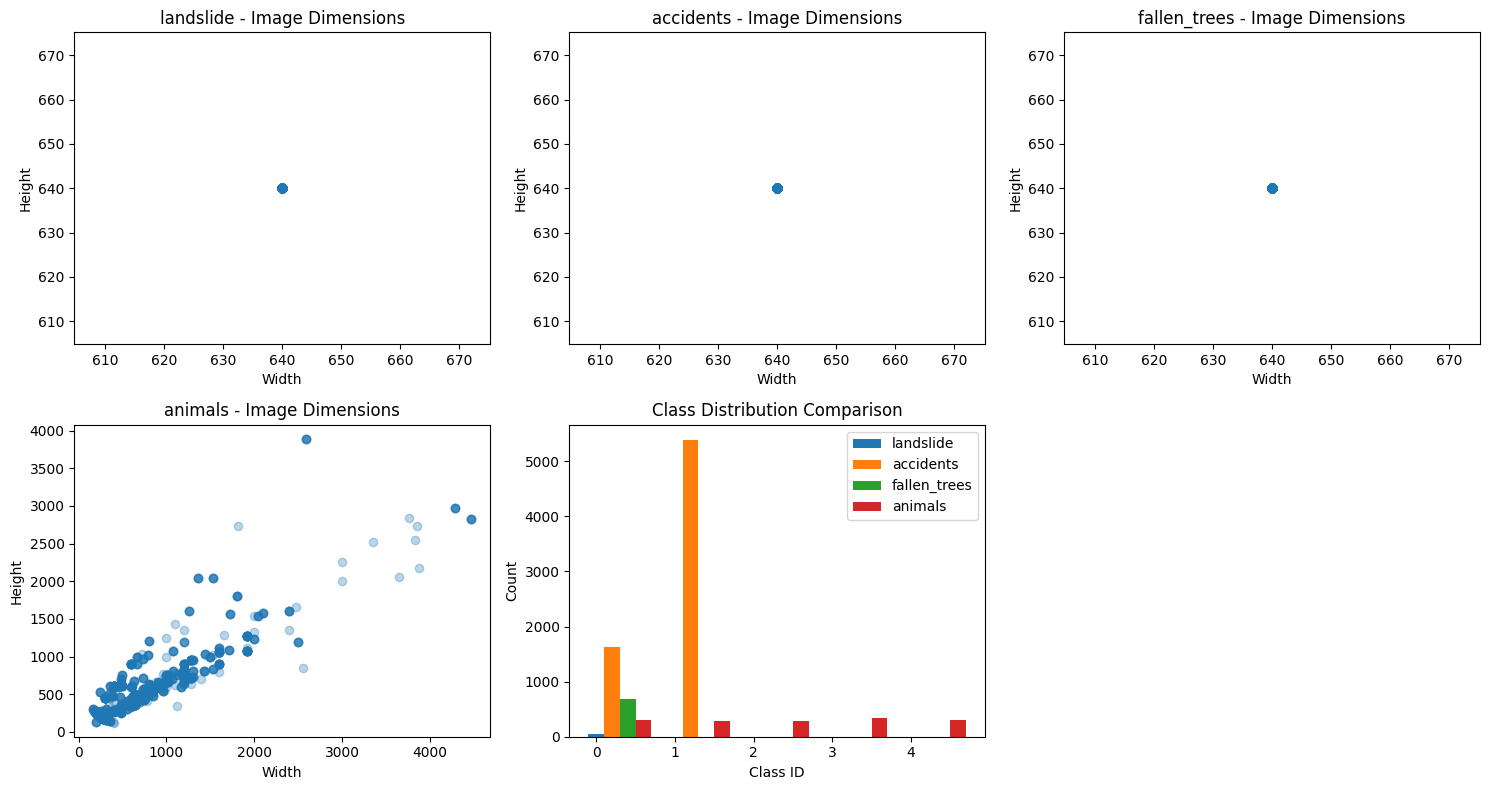


Preprocessing landslide dataset


Processing test split: 100%|██████████| 15/15 [00:00<00:00, 206.33it/s]



Processing Statistics for landslide:
Total Processed: 47
Skipped Images: 95
Invalid Labels: 132

Class Distribution:
0: 51
Dataset YAML created at: /kaggle/working/processed_data/landslide/dataset.yaml

Preprocessing accidents dataset


Processing test split: 100%|██████████| 675/675 [00:04<00:00, 136.00it/s]



Processing Statistics for accidents:
Total Processed: 6744
Skipped Images: 9
Invalid Labels: 0

Class Distribution:
1: 5390
0: 1629
Dataset YAML created at: /kaggle/working/processed_data/accidents/dataset.yaml

Preprocessing fallen_trees dataset


...

Speed: 0.5ms preprocess, 2.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/training_combined

Final Evaluation Results (Multitask):
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f921926feb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.0

val: Scanning /kaggle/working/processed_data/combined/valid/labels.cache... 884 images, 0 backgrounds, 0 corrupt: 100%|██████████| 884/884 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 56/56 [00:06<00:00,  8.62it/s]


                   all        884        942      0.637       0.58      0.601      0.378
             landslide          7          7          1          0     0.0648     0.0158
       accident_class0        141        142      0.547       0.69      0.626      0.419
       accident_class1        538        572      0.758      0.811      0.859      0.604
           fallen_tree         58         72      0.495      0.041      0.177     0.0467
                buffle         23         23      0.542      0.652      0.695      0.438
               guepard         27         28      0.378      0.536      0.614      0.403
           hippopotame         33         33      0.737      0.879      0.858       0.52
                  lion         30         33      0.562       0.66      0.553      0.348
                  loup         32         32      0.718      0.953      0.963      0.604


/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


Speed: 0.5ms preprocess, 2.2ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/training_combined

Comprehensive training report saved to: /kaggle/working/training_report.yaml

Training completed successfully!


In [ ]:
# %% Cell 11: Execute the Training Pipeline
# This is the entry point of the script. When the script is run directly,
# it sets up the logging, calls the main() function, and logs the status of the training pipeline.
if __name__ == "__main__":
    logger = setup_logging()
    try:
        logger.info("Starting multitask training pipeline with animals dataset included")
        main()
        logger.info("Training pipeline completed successfully")
    except Exception as e:
        logger.error(f"Training pipeline failed: {str(e)}", exc_info=True)
        raise